#PLEASE READ SHORT TEXT BELOW

Please find a clean notebook on the following github link :

https://github.com/Julien-website/Stochastic_Loc_Vol_Project/blob/travail-groupe/ComputingAssignment%20-%20AdvancedCalibrationMethodsAndVixDerivatives.ipynb

The results are provided with a better confidence (Number_sim = 10,000), which could not be run quickly enough here (we have thus chosen to reduce Number_sim to 1,000). Still, feel free to run the notebook, but the results might be not as relevant as the ones displayed on the github.

Thank you!

## Advanced calibration methods and VIX derivatives
### Master M2MO, Université Paris Cité
### Master 2 Probabilités et Finance, Sorbonne Université and École polytechnique
# Computing assignment 

### Due Date: 11:59 PM Sunday, April 12, 2026

You should turn in the notebook on the Moodle course website. You are expected to work in groups of 3 preferably, or possibly groups of 2.

Please comment your code properly.

Before you turn in the notebook, press the "Run all cells" button in the toolbar, and make sure all the calculation results and graphs are produced correctly in a reasonable time frame, and then save the notebook under the name ComputingAssignmentACMVix-FirstName1LastName1-FirstName2LastName2-FirstName3LastName3.ipynb

<h3 style="color:deepskyblue">1. The Particle Method for Smile Calibration</h3>

Consider the stochastic local volatility (SLV) model

$$
\begin{array}{l}
dS_t = a_t l(t, S_t) S_t dW^{(1)}_t\\
a_t=\sigma_0 e^{Y_t}\quad\text{where}\quad d Y_t = -\kappa Y_tdt+\gamma dW^{(2)}_t\\
d \langle W^{(1)}, W^{(2)} \rangle_t = \rho dt.
\end{array}
$$

The numerical values for the model parameters are
- $T = 1$.
- $S_0 = 100$.
- $\sigma_0 = 15\%$.
- $Y_0 = 0$.
- $\rho = -50\%$.
- $\gamma = 50\%$.
- $\kappa = 1$.

The goal is to find a leverage function $l(t, S)$ so that this model matches the market prices of vanilla options. For the sake of simplicity, we assume that the market implied volatility surface is flat $\sigma_{\textrm{Market}} \equiv 15\%$. In that case, we also have $\sigma_{\textrm{Dup}}(t,S) \equiv 15\%$.

Below we describe a Monte Carlo simulation scheme for the SLV model.

First we discretize the interval $(0,T)$ into subintervals $(t_{i-1}, t_i)$, $1\leq i\leq n$, and set $\Delta t_i=t_i-t_{i-1}$. 

The Ornstein-Uhlenbeck process $Y$ is explicitly solvable:
\begin{equation}
Y_{t_i}=e^{-\kappa\Delta t_i}Y_{t_{i-1}}+\int_{t_{i-1}}^{t_i}\gamma e^{-\kappa\left(t_i-s\right)}dW_s^{(2)}.
\end{equation}

Therefore for given $Y_{t_{i-1}}$, $Y_{t_i}$ is a Gaussian variable with 
\begin{equation}\tag{1}
\mathbb{E}\left[\left.Y_{t_i}\right\vert Y_{t_{i-1}}\right]=e^{-\kappa\Delta t_i}Y_{t_{i-1}},\quad
\text{Var}\left[\left.Y_{t_i}\right\vert Y_{t_{i-1}}\right]=\frac{\gamma^2}{2\kappa}\left(1-e^{-2\kappa\Delta t_i}\right)
\end{equation}

so that paths of $Y$ can be simulated exactly.

To simulate the spot process $S$, we use the Euler scheme:
$$\log S_{t_i}-\log S_{t_{i-1}}=-\frac{1}{2}\sigma_0^2e^{2Y_{t_{i-1}}}l(t_{i-1},S_{t_{i-1}})^2\Delta t_i+\sigma_0 e^{Y_{t_{i-1}}}l(t_{i-1},S_{t_{i-1}})\int_{t_{i-1}}^{t_i}dW^{(1)}_t$$

Thus for given $S_{t_{i-1}}$ and $Y_{t_{i-1}}$, $\log S_{t_i}$ and $Y_{t_i}$ are jointly Gaussian variables with

\begin{equation}\tag{2}
\mathbb{E}\left[\left.\log S_{t_i}\right\vert S_{t_{i-1}},Y_{t_{i-1}}\right]=\log S_{t_{i-1}}-\frac{1}{2}\sigma_0^2e^{2Y_{t_{i-1}}}\Delta t_i,\quad\text{Var}\left[\left.\log S_{t_i}\right\vert S_{i_{i-1}}, Y_{t_{i-1}}\right]=\sigma_0^2e^{2Y_{t_{i-1}}}l(t_{i-1},S_{t_{i-1}})^2\Delta t_i
\end{equation}

\begin{equation}\tag{3}
\text{Cov}\left[\left.Y_{t_i},\log S_{t_i}\right\vert S_{t_{i-1}}, Y_{t_{i-1}}\right]=\sigma_0 e^{Y_{t_{i-1}}}l(t_{i-1},S_{t_{i-1}})\frac{\gamma\rho}{\kappa}\left(1-e^{-\kappa\Delta t_i}\right)
\quad\text{or}\quad
\text{Corr}\left[\left.Y_{t_i},\log S_{t_i}\right\vert S_{t_{i-1}}, Y_{t_{i-1}}\right]=\rho\sqrt{\frac{2(1-e^{-\kappa\Delta t_i})}{\kappa\Delta t_i(1+e^{-\kappa\Delta t_i})}}
\end{equation}

Over the time interval $[t_{i-1}, t_i]$, we can advance $\log S$ and $Y$ by generating Gaussian variables $\log S_{t_i}$ and $Y_{t_i}$ using equations (1)-(3). That is,

\begin{align}
\log S_{t_i} &= \log S_{t_{i-1}}-\frac{1}{2}\sigma_0^2e^{2Y_{t_{i-1}}}l(t_{i-1},S_{t_{i-1}})^2\Delta t_i+\sigma_0e^{Y_{t_{i-1}}}l(t_{i-1},S_{t_{i-1}})\sqrt{\Delta t_i}\left(\sqrt{1-\bar{\rho}^2}Z_1+\bar{\rho}Z_2\right),\quad\text{where }\bar{\rho}=\rho\sqrt{\frac{2(1-e^{-\kappa\Delta t_i})}{\kappa\Delta t_i(1+e^{-\kappa\Delta t_i})}}\\
Y_{t_i} &= e^{-\kappa\Delta t_i}Y_{t_{i-1}}+\gamma\sqrt{\frac{1-e^{-2\kappa\Delta t_i}}{2\kappa}}Z_2
\end{align}
where $Z_1$ and $Z_2$ are independent standard normal variables.

<b>(a).</b> Implementation of the Particle Method.
- Implement the particle method studied in class to find the leverage function $l$. We suggest that for the kernel regression you use the quartic kernel

$$\delta(x)=(x+1)^2(1-x)^2\quad\text{for }-1\leq x\leq 1\quad\text{and}\quad0\quad\text{ elsewhere}$$

together with the bandwidth 

$$h = \kappa \sigma_{\mathrm{Market}} S_0 \sqrt{\max(t_k,0.15)}N^{-0.2}$$

at discretization date $t_k$. We recall that the rescaled kernel is 

$$ \delta_h(x) = \frac{1}{h}\delta\left(\frac{x}{h}\right). $$

Make sure to fine-tune the dimensionless bandwidth parameter $\kappa$. Its order of magnitude is 1.0. Use $\Delta t = 1/100$, $N=10,000$ paths. Note: In class, we described an acceleration technique that involves sorting the "particles" $(S_{t_k},a_{t_k})$ according to the spot value $S_{t_k}$. Since the kernel we have chosen has compact support and is fairly inexpensive to evaluate, you may ignore this acceleration technique here. This means that each estimation of a conditional expectation $\mathbb{E}\left[\left.a_{t_k}^2\right\vert S_{t_k}=x\right]$ (for $x$ in a grid $G_{t_k}$ of spot values) involves the ratio of two sums of $N$ terms each. For the minimum and maximum values of $G_{t_k}$, take the 0.1% and 99.9% quantiles of the risk-neutral distribution of $S$ at $t_k$, i.e., since the smile is flat at $\sigma_{\textrm{Market}}$, of the distribution of $S_0\exp(\sigma_{\textrm{Market}}\sqrt{t_k}G - \frac12 \sigma_{\textrm{Market}}^2 t_k)$, with $G$ a standard Gaussian random variable. We suggest that the grid $G_{t_k}$ contain 30 equally spaced spot values.

- Check that the resulting model is indeed calibrated to the market implied volatilities $\sigma_{\textrm{Market}} \equiv 15\%$. To this end, compute estimates of the call prices (maturity $T=1$) in the calibrated model for strikes $70, 80, 90, 100, 110, 120, 130, 140$, and invert the Black-Scholes formula to get the corresponding estimation of the implied volatilities $\hat\sigma(T,K)$. To estimate the call prices in the calibrated model, simulate a new set of independent paths with the calibrated leverage function $l$ and $N_2 = 100,000$ paths. For the inversion of the Black-Scholes formula, you can use the function <code>blackscholes_impv</code> provided below.

<b>(b).</b> Fix the spot-vol correlation $\rho = 0\%$ and mean reversion $\kappa=1$. We study the impact of volatility of volatility $\gamma$ on the smile in the pure stochastic volatility model and calibrated leverage function in the SLV model. Perform the following tasks with various values of $\gamma$. Suggested values of $\gamma$: $0\%$, $25\%$, $50\%$, $75\%$.
- Recalibrate the leverage function $l(t,S)$ for each $\gamma$, and plot the calibrated leverage function $l(t, S)$ as a function of the spot value $S$ for a fixed maturity, e.g., $t = T$ with various values of $\gamma$ in the same graph. Comment on the dependence of the shape of the leverage function on $\gamma$.
- Plot the corresponding smile at maturity $T$ for the pure stochastic volatility model (set the leverage function $l \equiv 1$) with the various values of $\gamma$ in the same graph. Comment on the dependence of the shape of the smile on $\gamma$.

<b>(c).</b> Fix the volatility of volatility $\gamma = 50\%$ and mean reversion $\kappa=1$. We study the impact of spot-vol correlation $\rho$ on the smile in the pure stochastic volatility model and calibrated leverage function in the SLV model. Perform the following tasks with various values of $\rho$. Suggested values of $\rho$: $-50\%$, $0\%$, $50\%$.
- Recalibrate the leverage function $l(t,S)$ for each $\rho$, and plot the calibrated leverage function $l(t, S)$ as a function of the spot value $S$ for a fixed maturity, e.g., $t = T$ with various values of $\rho$ in the same graph. Comment on the dependence of the shape of the leverage function on $\rho$.
- Plot the corresponding smile at maturity $T$ for the pure stochastic volatility model (set the leverage function $l \equiv 1$) with the various values of $\rho$ in the same graph. Comment on the dependence of the shape of the smile on $\rho$.

<b>(d).</b> Fix the spot-vol correlation $\rho = 0\%$ and volatility of volatility $\gamma = 50\%$. We study the impact of mean reversion $\kappa$ on the smile in the pure stochastic volatility model and calibrated leverage function in the SLV model. Perform the following tasks with various values of $\kappa$. Suggested values of $\kappa$: $0.1$, $1$, $10$.
- Recalibrate the leverage function $l(t,S)$ for each $\gamma$, and plot the calibrated leverage function $l(t, S)$ as a function of the spot value $S$ for a fixed maturity, e.g., $t = T$ with various values of $\gamma$ in the same graph. Comment on the dependence of the shape of the leverage function on $\kappa$.
- Plot the corresponding smile at maturity $T$ for the pure stochastic volatility model (set the leverage function $l \equiv 1$) with the various values of $\kappa$ in the same graph. Comment on the dependence of the shape of the smile on $\kappa$.

<b>(e).</b> Consider the forward-starting call spread with payoff
\begin{equation*}
50 \left(\left( \frac{S_{T_2}}{S_{T_1}}-0.99 \right)_+ - \left( \frac{S_{T_2}}{S_{T_1}}-1.01 \right)_+\right)
\end{equation*}
with $T_1 = T - \frac{1}{12}$, $T_2 = T$. Use $\gamma = 100\%$, $\rho = -80\%$ and $\kappa=4$. Compare the prices of this option in the Black-Scholes model with volatility 15% and in the calibrated SLV model. Comment on the result. Why is it of interest to use stochastic local volatility models for pricing derivatives?

In [1]:
'Packages'
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

In [2]:
#Please choose the number of simulations here. Basically set to 1000 (as 10,000 takes too much time)
NS = 10000

In [3]:
def blackscholes_price(K, T, S, vol, r=0, q=0, callput='call'):
    """Compute the call/put option price in Black-Scholes model
    
    Parameters
    ----------
    K: scalar or array_like
        The strike of the option.
    T: scalar or array_like
        The maturity of the option.
    S: scalar or array_like
        The spot price of the underlying security.
    vol: scalar or array_like
        The implied Black-Scholes volatility.
    callput: str
        Must be either 'call' or 'put'

    Returns
    -------
    price: scalar or array_like
        The price of the option.

    Examples
    --------
    >>> blackscholes_price(95, 0.25, 100, 0.2, r=0.05, callput='put')
    1.5342604771222823
    """
    F = S*np.exp((r-q)*T)
    w = vol**2*T
    d1 = (np.log(F/K)+0.5*w)/np.sqrt(w)
    d2 = d1 - np.sqrt(w)
    callput = callput.lower()
    if callput == 'call':
        opttype = 1
    elif callput == 'put':
        opttype = -1
    else:
        raise ValueError('The value of callput must be either "call" or "put".')
    price = (opttype*F*norm.cdf(opttype*d1)-opttype*K*norm.cdf(opttype*(d2)))*np.exp(-r*T)
    return price

In [4]:
# all inputs must be scalar
def blackscholes_impv_scalar(K, T, S, value, r=0, q=0, callput='call', tol=1e-6, maxiter=500):
    """Compute implied vol in Black-Scholes model
    
    Parameters
    ----------
    K: scalar
        The strike of the option.
    T: scalar
        The maturity of the option.
    S: scalar
        The spot price of the underlying security.
    value: scalar
        The value of the option
    callput: str
        Must be either 'call' or 'put'

    Returns
    -------
    vol: scalar
        The implied vol of the option.
    """
    if (K <= 0) or (T <= 0):
        return np.nan
    F = S*np.exp((r-q)*T)
    K = K/F
    value = value*np.exp(r*T)/F
    callput = callput.lower()
    if callput not in ['call', 'put']:
        raise ValueError('The value of "callput" must be either "call" or "put"')
    opttype = 1 if callput == 'call' else -1
    value -= max(opttype * (1 - K), 0)
    if value < 0:
        return np.nan
    if (value == 0):
        return 0
    j = 1
    p = np.log(K)
    if K >= 1:
        x0 = np.sqrt(2 * p)
        x1 = x0 - (0.5 - K * norm.cdf(-x0) - value) * np.sqrt(2*np.pi)
        while (abs(x0 - x1) > tol*np.sqrt(T)) and (j < maxiter):
            x0 = x1
            d1 = -p/x1+0.5*x1
            x1 = x1 - (norm.cdf(d1) - K*norm.cdf(d1-x1)-value)*np.sqrt(2*np.pi)*np.exp(0.5*d1**2)
            j += 1
        return x1 / np.sqrt(T)
    else:
        x0 = np.sqrt(-2 * p)
        x1 = x0 - (0.5*K-norm.cdf(-x0)-value)*np.sqrt(2*np.pi)/K
        while (abs(x0-x1) > tol*np.sqrt(T)) and (j < maxiter):
            x0 = x1
            d1 = -p/x1+0.5*x1
            x1 = x1-(K*norm.cdf(x1-d1)-norm.cdf(-d1)-value)*np.sqrt(2*np.pi)*np.exp(0.5*d1**2)
            j += 1
        return x1/np.sqrt(T)

# vectorized version
blackscholes_impv = np.vectorize(blackscholes_impv_scalar, excluded={'callput', 'tol', 'maxiter'})

# Example
blackscholes_impv(K=95, T=0.25, S=100, value=7, callput='call')

array(0.20654803)

In [5]:
def quartic_kernel(x):
    x = np.clip(x, -1, 1)
    return (x+1)**2*(1-x)**2

ANSWERS PART I BELOW

<b>(a).</b> Implementation of the Particle Method.

In [6]:
'Introduction of key parameters'
T = 1
S0 = 100
sigma0 = 0.15
Y0 = 0
rho = -0.5
gamma = 0.5
kappa = 1
a0 = sigma0 * np.exp(Y0)
Ndates= 100
t = np.linspace(0,T,Ndates+1)

def h(t_k,sigma_market = 0.15, kappa_band = 1, N = 10000, S0 = 100):
    return kappa*sigma_market*S0*np.sqrt(max(t_k,0.15)) * N**(-0.2)

In [7]:
'Constructing the grid'

Gmin = norm.ppf(0.001)
Gmax = norm.ppf(0.999)

grid = [None]

for k in range(1, len(t)):
    Smin = S0 * np.exp(sigma0 * np.sqrt(t[k]) * Gmin - 0.5 * sigma0**2 * t[k] )
    Smax = S0 * np.exp(sigma0 * np.sqrt(t[k]) * Gmax - 0.5 * sigma0**2 * t[k] )
    gridk = np.linspace(Smin, Smax, 30)
    grid.append(gridk)

In [8]:
def calibrate_leverage(
    gamma,
    t,
    grid,
    S0,
    Y0,
    sigma0,
    rho,
    kappa,
    N=NS,
    T=1
):

    'Starting simulations'

    dt = T / 100
    sigma_market = 0.15

    S = [S0] * N
    Y = [Y0] * N
    a = [sigma0 * np.exp(Y0)] * N

    rhobar = rho * np.sqrt(2 * (1 - np.exp(-kappa * dt)) / (kappa * dt * (1 + np.exp(-kappa * dt))))

    l_values = [None] * len(t)
    l_values[0] = [1.0] * 30   #Initializing for t = 0


    'First step: t0 -> t1 (l = 1 evrywhere)'

    for i in range(N):
        Z1 = np.random.normal(0, 1)
        Z2 = np.random.normal(0, 1)
        Z = np.sqrt(1 - rhobar**2) * Z1 + rhobar * Z2

        Y_old = Y[i]
        S_old = S[i]
        a_old = sigma0 * np.exp(Y_old)

        Y[i] = np.exp(-kappa * dt) * Y_old + gamma * np.sqrt((1 - np.exp(-2 * kappa * dt)) / (2 * kappa)) * Z2
        logS_i = np.log(S_old) - 0.5 * (a_old**2) * dt + a_old * np.sqrt(dt) * Z
        S[i] = np.exp(logS_i)
        a[i] = sigma0 * np.exp(Y[i])


    'Main loop: build l(t_k, .), interpolate it, simulate to t_k+1'

    for k in range(1, len(t) - 1):

        # 1) estimate E[a^2 | S = x] on grid[k]
        EV_conditional_a = []
        hk = h(t[k], sigma_market=sigma_market, kappa_band=1.0, N=N, S0=S0)

        for x in grid[k]:
            numerator = 0.0
            denominator = 0.0

            for i in range(N):
                weight = (1 / hk) * quartic_kernel((S[i] - x) / hk)
                numerator += (a[i]**2) * weight
                denominator += weight

            if denominator > 0:
                EV_conditional_a.append(numerator / denominator)
            else:
                EV_conditional_a.append(sigma_market**2)

        # 2) leverage on grid[k]
        l_values[k] = [sigma_market / np.sqrt(value) for value in EV_conditional_a]

        # 3) simulate from t_k to t_k+1 using interpolated leverage
        for i in range(N):
            Z1 = np.random.normal(0, 1)
            Z2 = np.random.normal(0, 1)
            Z = np.sqrt(1 - rhobar**2) * Z1 + rhobar * Z2

            Y_old = Y[i]
            S_old = S[i]
            a_old = sigma0 * np.exp(Y_old)

            # interpolation of l(t_k, S_old)
            l_current = np.interp(S_old, grid[k], l_values[k], left=l_values[k][0], right=l_values[k][-1])

            Y[i] = np.exp(-kappa * dt) * Y_old + gamma * np.sqrt((1 - np.exp(-2 * kappa * dt)) / (2 * kappa)) * Z2
            logS_i = np.log(S_old) - 0.5 * (a_old**2) * (l_current**2) * dt + a_old * l_current * np.sqrt(dt) * Z
            S[i] = np.exp(logS_i)
            a[i] = sigma0 * np.exp(Y[i])


    'Finally: compute l at final maturity t_n as well'

    EV_conditional_a = []
    hk = h(t[-1], sigma_market=sigma_market, kappa_band=1.0, N=N, S0=S0)

    for x in grid[-1]:
        numerator = 0.0
        denominator = 0.0

        for i in range(N):
            weight = (1 / hk) * quartic_kernel((S[i] - x) / hk)
            numerator += (a[i]**2) * weight
            denominator += weight

        if denominator > 0:
            EV_conditional_a.append(numerator / denominator)
        else:
            EV_conditional_a.append(sigma_market**2)

    l_values[-1] = [sigma_market / np.sqrt(value) for value in EV_conditional_a]
    return l_values

Let's now test whether we have calibrated the volatility correctly by computing the prices of several calls

In [9]:
def simulate_terminal_spot(
    gamma,
    t,
    grid,
    l_values,
    S0,
    Y0,
    sigma0,
    rho,
    kappa,
    N=NS,
    N2=10000,
    T=1
):

    dt = T / 100

    S_MC = [S0] * N2
    Y_MC = [Y0] * N2

    rhobar = rho * np.sqrt(2 * (1 - np.exp(-kappa * dt)) / (kappa * dt * (1 + np.exp(-kappa * dt))))

    # simulation
    for k in range(len(t) - 1):

        for i in range(N2):

            Z1 = np.random.normal(0, 1)
            Z2 = np.random.normal(0, 1)
            Z = np.sqrt(1 - rhobar**2) * Z1 + rhobar * Z2

            Y_old = Y_MC[i]
            S_old = S_MC[i]
            a_old = sigma0 * np.exp(Y_old)

            if k == 0:
                l_current = 1.0
            else:
                l_current = np.interp(
                    S_old,
                    grid[k],
                    l_values[k],
                    left=l_values[k][0],
                    right=l_values[k][-1]
                )

            # update Y
            Y_MC[i] = np.exp(-kappa * dt) * Y_old + gamma * np.sqrt((1 - np.exp(-2 * kappa * dt)) / (2 * kappa)) * Z2

            # update S
            logS = np.log(S_old) - 0.5 * (a_old**2) * (l_current**2) * dt + a_old * l_current * np.sqrt(dt) * Z
            S_MC[i] = np.exp(logS)

    return S_MC

In [10]:
def impvd_volatility(
    gamma,
    t,
    grid,
    l_values,
    S0,
    Y0,
    sigma0,
    rho,
    kappa,
    N=NS,
    N2=10000,
    T=1
):

    S_MC = simulate_terminal_spot(
        gamma,
        t,
        grid,
        l_values,
        S0=S0,
        Y0=Y0,
        sigma0=sigma0,
        rho=rho,
        kappa=kappa,
        N=N,
        N2=N2,
        T=T
    )

    strikes = [70, 80, 90, 100, 110, 120, 130, 140]
    prices = [0] * len(strikes)

    # pricing
    for S in S_MC:
        for i in range(len(strikes)):
            prices[i] += max(0, S - strikes[i])

    for i in range(len(prices)):
        prices[i] *= 1 / N2

    # implied vols
    impvdict = {}

    for i in range(len(prices)):
        K = strikes[i]
        impvdict[K] = blackscholes_impv_scalar(
            K,
            T=T,
            S=S0,
            value=prices[i],
            r=0,
            q=0,
            callput='call'
        )

    return impvdict

In [11]:
l_values = calibrate_leverage(
    gamma,
    t,
    grid,
    S0,
    Y0,
    sigma0,
    rho,
    kappa,
    N=NS,
    T=1
)

res = impvd_volatility(
    0.5, 
    t, 
    grid,
    l_values,
    S0,
    Y0,
    sigma0,
    rho,
    kappa)

for K in res:
    print(K, res[K])

70 nan
80 0.14287767227022535
90 0.14745316905669817
100 0.14802469469516838
110 0.14842593428557588
120 0.1483170946158588
130 0.1489800530161618
140 0.15106890299333164


The results seem consistent regarding what we are expecting (15% for every strike). The NAN resulte for K = 70 may be linked to the fact that the impvd inverse function may stop if if ST-K is too small at some point.

Question 1b)

In [12]:
rho = 0

l_values = calibrate_leverage(
    gamma,
    t,
    grid,
    S0,
    Y0,
    sigma0,
    rho,
    kappa,
    N=NS,
    T=1
)

In [13]:
gammas = [0.0, 0.25, 0.5, 0.75]

for g in gammas:
    vols = impvd_volatility(g, 
    t, 
    grid,
    l_values,
    S0,
    Y0,
    sigma0,
    rho,
    kappa)
    print("gamma =", g)
    print(vols)

gamma = 0.0
{70: nan, 80: 0.12855533423217683, 90: 0.14013704321155931, 100: 0.14256818063207452, 110: 0.14194113040471942, 120: 0.1382765607573993, 130: 0.13479838786741336, 140: 0.13009659829460138}
gamma = 0.25
{70: nan, 80: nan, 90: 0.13280334291597043, 100: 0.13895971245643773, 110: 0.13999564385463428, 120: 0.13888869436879203, 130: 0.1362271674208363, 140: 0.1321237228080446}
gamma = 0.5
{70: 0.18488707714387825, 80: 0.15773236337175475, 90: 0.15224549583860036, 100: 0.15138407292164843, 110: 0.15086020098441497, 120: 0.15117933192254288, 130: 0.150805737869416, 140: 0.15171317787131375}
gamma = 0.75
{70: 0.1741755188599829, 80: 0.1658662358897717, 90: 0.1607013158131209, 100: 0.15877490989988716, 110: 0.15934654007448007, 120: 0.16197602828527555, 130: 0.16634865211950434, 140: 0.1704769933847233}


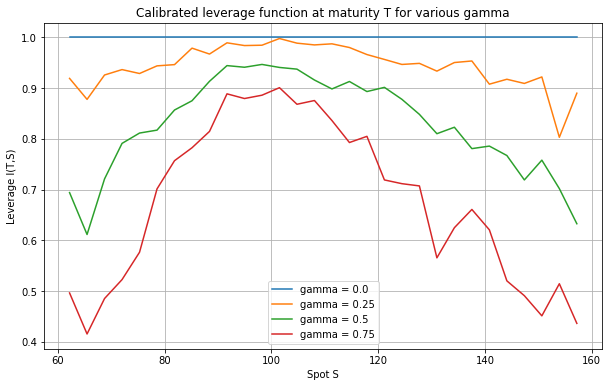

In [14]:
gammas = [0.0, 0.25, 0.5, 0.75]

plt.figure(figsize=(10, 6))

for g in gammas:
    l_values = calibrate_leverage(
        g,
        t,
        grid,
        S0,
        Y0,
        sigma0,
        rho,
        kappa = 1,
        N=NS,
        T=1
    )

    plt.plot(grid[-1], l_values[-1], label=f"gamma = {g}")

plt.xlabel("Spot S")
plt.ylabel("Leverage l(T,S)")
plt.title("Calibrated leverage function at maturity T for various gamma")
plt.legend()
plt.grid(True)
plt.show()

For gamma = 0, the leverage function is flat and close to 1, as expected since there is no stochastic volatility.
As gamma increases, the leverage function becomes more irregular and deviates more from 1, reflecting the increasing impact of stochastic volatility.
For larger gamma values, the estimated leverage function becomes noisier, especially in the wings, due to Monte Carlo noise and kernel estimation instability.
This effect is amplified by the relatively small number of simulated particles used for computational efficiency.

In [15]:
"Let's redo a function similar to the one of 1a) but with l = 1"

def simulate_terminal_spot_pure_sv(
    gamma,
    t,
    S0,
    Y0,
    sigma0,
    rho,
    kappa,
    N2=10000,
    T=1
):
    dt = T / 100

    S_MC = [S0] * N2
    Y_MC = [Y0] * N2

    rhobar = rho * np.sqrt(2 * (1 - np.exp(-kappa * dt)) / (kappa * dt * (1 + np.exp(-kappa * dt))))

    for k in range(len(t) - 1):
        for i in range(N2):
            Z1 = np.random.normal(0, 1)
            Z2 = np.random.normal(0, 1)
            Z = np.sqrt(1 - rhobar**2) * Z1 + rhobar * Z2

            Y_old = Y_MC[i]
            S_old = S_MC[i]
            a_old = sigma0 * np.exp(Y_old)

            # pure SV: leverage identically equal to 1
            l_current = 1

            # update Y
            Y_MC[i] = np.exp(-kappa * dt) * Y_old + gamma * np.sqrt((1 - np.exp(-2 * kappa * dt)) / (2 * kappa)) * Z2

            # update S
            logS = np.log(S_old) - 0.5 * (a_old**2) * dt + a_old * np.sqrt(dt) * Z
            S_MC[i] = np.exp(logS)

    return S_MC

In [16]:
def implied_volatility_pure_sv(
    gamma,
    t,
    S0,
    Y0,
    sigma0,
    rho,
    kappa,
    N2=10000,
    T=1
):
    S_MC = simulate_terminal_spot_pure_sv(
        gamma,
        t,
        S0,
        Y0,
        sigma0,
        rho,
        kappa,
        N2=N2,
        T=T
    )

    strikes = [70, 80, 90, 100, 110, 120, 130, 140]
    prices = [0] * len(strikes)

    for S in S_MC:
        for i in range(len(strikes)):
            prices[i] += max(0, S - strikes[i])

    for i in range(len(prices)):
        prices[i] *= 1 / N2

    impvdict = {}

    for i in range(len(prices)):
        K = strikes[i]
        impvdict[K] = blackscholes_impv_scalar(
            K,
            T=T,
            S=S0,
            value=prices[i],
            r=0,
            q=0,
            callput='call'
        )

    return impvdict

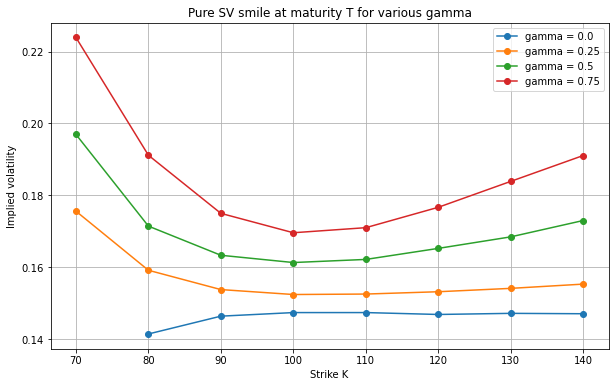

In [17]:
import matplotlib.pyplot as plt

gammas = [0.0, 0.25, 0.5, 0.75]

plt.figure(figsize=(10, 6))

for g in gammas:
    impvdict = implied_volatility_pure_sv(
        g,
        t,
        S0,
        Y0,
        sigma0,
        rho=0.0,   # imposed in question 1(b)
        kappa=1.0, # imposed in question 1(b)
        N2=10000,
        T=1
    )

    strikes = list(impvdict.keys())
    vols = list(impvdict.values())

    plt.plot(strikes, vols, marker='o', label=f"gamma = {g}")

plt.xlabel("Strike K")
plt.ylabel("Implied volatility")
plt.title("Pure SV smile at maturity T for various gamma")
plt.legend()
plt.grid(True)
plt.show()

For gamma = 0, the model reduces to a deterministic volatility model, and the implied volatility surface is flat, as expected.
As γ increases, the volatility of volatility increases, introducing randomness in the instantaneous volatility.
This results in a mixture of lognormal distributions for the terminal spot, which generates a volatility smile.
The smile becomes more pronounced as γ increases.
Since ρ = 0, the smile is approximately symmetric around the at-the-money strike.

Question 1c

In [18]:
gamma = 0.5
kappa = 1

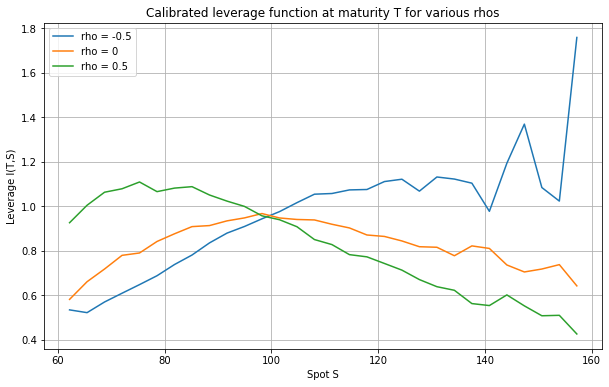

In [19]:
rhos = [-0.5, 0, 0.5]

plt.figure(figsize=(10, 6))

for r in rhos:
    l_values = calibrate_leverage(
        gamma,
        t,
        grid,
        S0,
        Y0,
        sigma0,
        r,
        kappa = 1,
        N=NS,
        T=1
    )

    plt.plot(grid[-1], l_values[-1], label=f"rho = {r}")

plt.xlabel("Spot S")
plt.ylabel("Leverage l(T,S)")
plt.title("Calibrated leverage function at maturity T for various rhos")
plt.legend()
plt.grid(True)
plt.show()

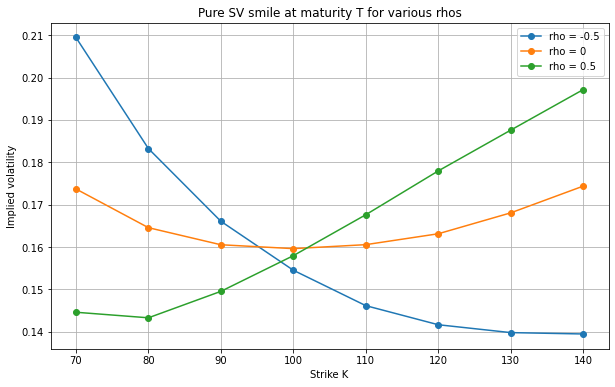

In [20]:
rhos = [-0.5, 0, 0.5]

plt.figure(figsize=(10, 6))

for r in rhos:
    impvdict = implied_volatility_pure_sv(
        gamma,
        t,
        S0,
        Y0,
        sigma0,
        rho=r,   
        kappa=1,
        N2=10000,
        T=1
    )

    strikes = list(impvdict.keys())
    vols = list(impvdict.values())

    plt.plot(strikes, vols, marker='o', label=f"rho = {r}")

plt.xlabel("Strike K")
plt.ylabel("Implied volatility")
plt.title("Pure SV smile at maturity T for various rhos")
plt.legend()
plt.grid(True)
plt.show()


For rho = 0, the pure stochastic volatility model generates a roughly symmetric smile.
For negative rho, the smile becomes a decreasing skew, which is the standard equity pattern.
For positive rho, the skew is reversed and implied volatility increases with strike.

Question 1d

In [21]:
rho = 0
gamma = 0.5

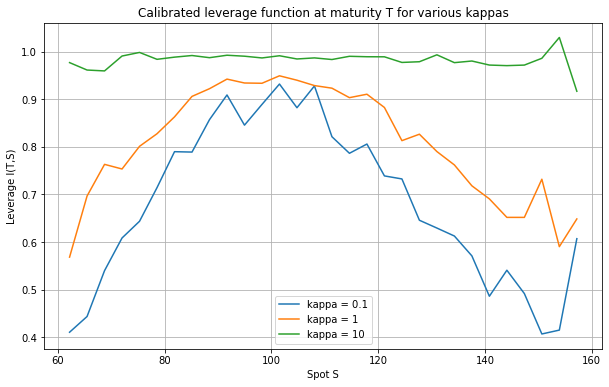

In [22]:
kappas = [0.1,1,10]

plt.figure(figsize=(10, 6))

for k in kappas:
    l_values = calibrate_leverage(
        gamma,
        t,
        grid,
        S0,
        Y0,
        sigma0,
        rho,
        kappa = k,
        N=NS,
        T=1
    )

    plt.plot(grid[-1], l_values[-1], label=f"kappa = {k}")

plt.xlabel("Spot S")
plt.ylabel("Leverage l(T,S)")
plt.title("Calibrated leverage function at maturity T for various kappas")
plt.legend()
plt.grid(True)
plt.show()

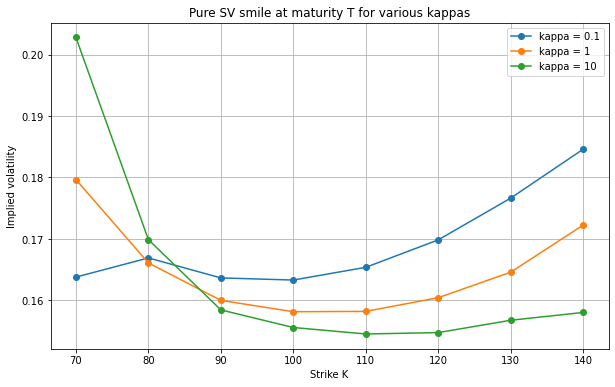

In [23]:
kappas = [0.1,1,10]

plt.figure(figsize=(10, 6))

for k in kappas:
    impvdict = implied_volatility_pure_sv(
        gamma,
        t,
        S0,
        Y0,
        sigma0,
        rho,   
        kappa=k,
        N2=10000,
        T=1
    )

    strikes = list(impvdict.keys())
    vols = list(impvdict.values())

    plt.plot(strikes, vols, marker='o', label=f"kappa = {k}")

plt.xlabel("Strike K")
plt.ylabel("Implied volatility")
plt.title("Pure SV smile at maturity T for various kappas")
plt.legend()
plt.grid(True)
plt.show()

The parameter kappa controls the speed of mean reversion of the volatility process.
For small kappa, volatility is highly persistent, leading to a larger dispersion of future variance and a pronounced volatility smile.
As kappa increases, volatility reverts more quickly to its mean, reducing the variability of the instantaneous variance and thus flattening the smile.
For large kappa, the model behaves close to a constant volatility model, and the implied volatility surface becomes nearly flat.
The calibrated leverage function reflects this effect: it becomes flatter as kappa increases.

Question 1e

Let's first compute the Black & Scholes price of the option which payoff is 
\begin{equation*}
50 \left(\left( \frac{S_{T_2}}{S_{T_1}}-0.99 \right)_+ - \left( \frac{S_{T_2}}{S_{T_1}}-1.01 \right)_+\right)
\end{equation*}
with $T_1 = T - \frac{1}{12}$, $T_2 = T$. Use $\gamma = 100\%$, $\rho = -80\%$ and $\kappa=4$

Under Black & Scholes assumptions, we use the fact that
\begin{equation*}
\frac{S_{T_2}}{S_{T_1}}, \frac{S_{T_2 - T_1} }{S_{0}} 
\end{equation*} 
have the same distribution. We can therefore use the Black & Scholes function already implemented.

In [24]:

T = 1/12
S0 = 1
K_low = 0.99
K_high = 1.01
sigma0 = 15/100

In [25]:
print("Black & Scholes Price", 50 * (blackscholes_price(K_low, T, S0, sigma0, r=0, q=0, callput='call') - blackscholes_price(K_high, T, S0, sigma0, r=0, q=0, callput='call')))

Black & Scholes Price 0.4915905629509276


Let's now compute the SLV price with the required parameters. This time we will have to compute a MC approximation thanks to the functions implemented earlier

In [26]:
T2 = 1
T1 = 11/12
S0 = 100
rho = -0.8
gamma = 1
kappa = 4
sigma0 = 0.15
Y0 = 0
a0 = sigma0 * np.exp(Y0)
Ndates= 120 #better than 100 in order to have T1 in the grid...
t = np.linspace(0, T2, Ndates + 1)
idx_T1 = int(T1 * Ndates)   # = 110
dt = T2 / Ndates

In [27]:
# Let's build the grid
grid = [None]
Gmin = norm.ppf(0.001)
Gmax = norm.ppf(0.999)

for k in range(1, len(t)):
    Smin = S0 * np.exp(sigma0 * np.sqrt(t[k]) * Gmin - 0.5 * sigma0**2 * t[k])
    Smax = S0 * np.exp(sigma0 * np.sqrt(t[k]) * Gmax - 0.5 * sigma0**2 * t[k])
    gridk = np.linspace(Smin, Smax, 30)
    grid.append(gridk)

# calibrate once and for all
l_values = calibrate_leverage(
    gamma,
    t,
    grid,
    S0,
    Y0,
    sigma0,
    rho,
    kappa,
    N=NS,
    T=T2
)

# pricing MC under calibrated SLV
N2 = 10000
S_MC = [S0] * N2
Y_MC = [Y0] * N2
S_T1 = [0.0] * N2

rhobar = rho * np.sqrt(2 * (1 - np.exp(-kappa * dt)) / (kappa * dt * (1 + np.exp(-kappa * dt))))

for k in range(len(t) - 1):
    for i in range(N2):
        Z1 = np.random.normal(0, 1)
        Z2 = np.random.normal(0, 1)
        Z = np.sqrt(1 - rhobar**2) * Z1 + rhobar * Z2

        Y_old = Y_MC[i]
        S_old = S_MC[i]
        a_old = sigma0 * np.exp(Y_old)

        if k == 0:
            l_current = 1.0
        else:
            l_current = np.interp(
                S_old,
                grid[k],
                l_values[k],
                left=l_values[k][0],
                right=l_values[k][-1]
            )

        Y_MC[i] = np.exp(-kappa * dt) * Y_old + gamma * np.sqrt((1 - np.exp(-2 * kappa * dt)) / (2 * kappa)) * Z2
        logS = np.log(S_old) - 0.5 * (a_old**2) * (l_current**2) * dt + a_old * l_current * np.sqrt(dt) * Z
        S_MC[i] = np.exp(logS)

    if k + 1 == idx_T1:
        S_T1 = S_MC.copy()

S_T2 = S_MC.copy()

payoffs = []
for i in range(N2):
    R = S_T2[i] / S_T1[i]
    payoff = 50 * (max(R - 0.99, 0) - max(R - 1.01, 0))
    payoffs.append(payoff)

price_slv = np.mean(payoffs)
print("SLV price =", price_slv)

SLV price = 0.5239824756351781


Although in this particular example the Black-Scholes and SLV prices are close, this is mainly due to the short time interval and the nearly symmetric payoff around 1.

In general, Black-Scholes models, even when calibrated to vanilla options, fail to capture the correct dynamics of the underlying asset. In particular, they do not account for the stochastic nature of volatility and its interaction with the spot.

Stochastic local volatility models combine the advantages of local volatility (exact calibration to vanilla options) and stochastic volatility (realistic dynamics). This makes them more suitable for pricing path-dependent or forward-starting derivatives, such as the ratio payoff considered here.

Therefore, SLV models are of interest because they provide more accurate pricing for exotic derivatives that depend on the joint distribution of the asset at multiple times.

<h3 style="color:deepskyblue">2. Pricing SPX options, VIX futures and VIX options in the two-factor Bergomi model</h3>

The objective of this second part of the computing assignment is to price SPX options, VIX futures, and VIX options in the two-factor Bergomi model

\begin{eqnarray}
S_t &=& S_0 \exp\left(\int_0^t \sqrt{\xi_s^s}dW_s - \frac{1}{2}\int_0^t \xi_s^s ds \right) \\
    X_t^j &=& e^{-k_j t} \int_0^t e^{k_j s} \, dZ^j_s, \qquad j\in\{1,2\} \\
\alpha_\theta &=& \left( (1-\theta)^2 +\theta^2+2 \rho_{12}\theta(1-\theta)\right)^{-1/2} \\
x_t^u &=& \alpha_\theta \left((1-\theta)e^{-k_1(u-t)}X_t^1 + \theta e^{-k_2(u-t)}X_t^2 \right) \\
\xi_t^u &=& \xi_0^u g^u(t,x_t^u) \;\; = \;\;\xi_0^u f^u(t,X_t^1,X_t^2) \\
g^u(t,x) &=& \exp\left(\omega x - \frac{\omega^2}{2}\chi(t,u)\right) \\
\chi(t,u) &=& \alpha_\theta^2\left( (1-\theta)^2e^{-2k_1(u-t)} \text{Var}(X_t^1) + \theta^2e^{-2k_2(u-t)} \text{Var}(X_t^2) \right. \\
&& \left. + 2\theta(1-\theta)e^{-(k_1+k_2)(u-t)}\text{Cov}(X_t^1,X_t^2)\right) \\
d\langle W,Z^1\rangle_t &=& \rho_{S1} dt \\
d\langle W,Z^2\rangle_t &=& \rho_{S2} dt \\
d\langle Z^1,Z^2\rangle_t &=& \rho_{12} dt \\
\end{eqnarray}

In [28]:
import numpy as np

from scipy.stats import norm
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (4.8, 3.2)

from math import exp, sqrt, log, pi, sin, cos, atan, tan

In [29]:
from py_vollib.black_scholes.implied_volatility import implied_volatility
vec_find_vol_rat = np.vectorize(implied_volatility)   # a better imp vol estimator based on P Jäckel Let's be rational

## Pricing SPX options

1. By doing a Cholesky decomposition, give a necessary and sufficient condition (*) on $\rho_{S1},\rho_{S2},\rho_{12}$ so that
$$\begin{bmatrix}1 & \rho_{S1} & \rho_{S2}\\ \rho_{S1} & 1 & \rho_{12} \\ \rho_{S2} & \rho_{12} & 1\end{bmatrix}$$
is a correlation matrix.

Below we describe a Monte Carlo simulation scheme for the two-factor Bergomi model.

First we discretize the interval $(0,T)$ into subintervals $(t_{i-1}, t_i)$, $1\leq i\leq n$, and set $\Delta t_i=t_i-t_{i-1}$. 

The Ornstein-Uhlenbeck process $X^j$ is explicitly solvable:
\begin{equation}
X^j_{t_i}=e^{-k_j\Delta t_i}X^j_{t_{i-1}}+\int_{t_{i-1}}^{t_i} e^{-k_j\left(t_i-s\right)}dZ_s^{j}.
\end{equation}
so that paths of $X^j$ can be simulated exactly.

To simulate the spot process $S$, we use the Euler scheme on the log (by abuse of notation, below, S will denote the Euler scheme, not the true asset price process):
$$\log S_{t_i}-\log S_{t_{i-1}}=-\frac{1}{2}\xi_{t_{i-1}}^{t_{i-1}}\Delta t_i+\sqrt{\xi_{t_{i-1}}^{t_{i-1}}}\int_{t_{i-1}}^{t_i}dW_t$$

Thus given $(S_{t_{i-1}},X^1_{t_{i-1}},X^2_{t_{i-1}})$, $(\log S_{t_i},X^1_{t_i},X^2_{t_i})$ is a Gaussian vector.

2. Compute the mean vector and covariance matrix of this Gaussian vector.

This is what we will use to iteratively simulate $(\log S_{t_i},X^1_{t_i},X^2_{t_i})$.

3. Fill in the blanks in the code below.


In [30]:
vov = 4 
k_1 = 20
k_2 = 1.5
theta = 0.75
xi_0 = 0.025
rho_sx1,rho_sx2,rho_x1x2 = -0.8, -0.7, 0.7
T = 1

In [31]:
S_0 = 100

In [32]:
n_steps = 500
N_sims = 100000

4. Vary the parameters vov, k_1, k_2, theta, rho_sx1, rho_sx2, rho_x1x2 and T and comment on the impact on the SPX smile.

## Pricing VIX futures and VIX options

5. Prove that $(\xi_t^u)_{t\in[0,u]}$ is a martingale in $t$, for fixed $u>0$.
Denote $\sigma_t^2 = \xi_t^t$. Prove that $\xi_T^u = \mathbb{E}[\sigma_u^2|\mathcal{F}_T]$ and deduce that
$$\text{VIX}^2_T = \frac{1}{\tau}\int_T^{T+\tau} \xi_T^u du$$
where $\tau=30/365$ (30 days). Prove that, as a result, in the two-factor Bergomi model, there exists a function $\psi$ such that
$$\text{VIX}_T = \psi(T,X_T^1,X_T^2)$$
and write down the function $\psi$.

Since the vector $(X_T^1,X_T^2)$ is Gaussian, the price $\mathbb{E}[h(\text{VIX}_T)]$ of a VIX option $h(\text{VIX}_T)$ can very efficiently be estimated by a Gauss-Hermite quadrature; see 
https://en.wikipedia.org/wiki/Gaussian_quadrature and 
https://numpy.org/doc/stable/reference/generated/numpy.polynomial.hermite.hermgauss.html

6. Using this method, price a VIX future maturing at $T$ (choose $T=1/12$ (1 month), $2/12$, $3/12$, $4/12$) and VIX call options with the same maturity; take strikes with log-moneyness from -0.2 to 2.5, based on the price of the VIX future. Vary the number of points in the quadrature: 10, 20, 30, 50. What do you observe? Using 50 points in the quadrature, plot the VIX smile, using the Black formula (with spot value the value of the VIX future) to compute the VIX implied volatilities.

7. Comment on the impact of the vol-of-vol on the price of the VIX future and on the VIX implied volatilities. In the one-factor Bergomi model ($\theta=0$), comment on the impact of the mean reversion on the VIX implied volatilities: take $k_1 = 1,5,10,30,60,100$.

Réponses à l'exercice 2 ci-dessous

Question 1

We consider the symmetric matrix

$$
R=
\begin{pmatrix}
1 & \rho_{S1} & \rho_{S2}\\
\rho_{S1} & 1 & \rho_{12}\\
\rho_{S2} & \rho_{12} & 1
\end{pmatrix}.
$$

We seek a necessary and sufficient condition on  
$\rho_{S1}, \rho_{S2}, \rho_{12}$ for $R$ to be a correlation matrix.

A symmetric matrix with ones on the diagonal is a correlation matrix if and only if it is **positive semidefinite**.

We perform a Cholesky decomposition $R = LL^\top$ with

$$
L=
\begin{pmatrix}
1 & 0 & 0\\
\rho_{S1} & \sqrt{1-\rho_{S1}^2} & 0\\
\rho_{S2} & \ell_{32} & \ell_{33}
\end{pmatrix}.
$$

By identifying the coefficients, we obtain

$$
\rho_{12}
=
\rho_{S1}\rho_{S2}
+
\sqrt{1-\rho_{S1}^2}\,\ell_{32},
$$

hence

$$
\ell_{32}
=
\frac{\rho_{12}-\rho_{S1}\rho_{S2}}{\sqrt{1-\rho_{S1}^2}}.
$$

Next,

$$
\ell_{33}^2 = 1-\rho_{S2}^2-\ell_{32}^2.
$$

The condition $\ell_{33}^2 \ge 0$ yields

$$
1-\rho_{S2}^2-\frac{(\rho_{12}-\rho_{S1}\rho_{S2})^2}{1-\rho_{S1}^2} \ge 0.
$$

After simplification,

$$
1 + 2\rho_{S1}\rho_{S2}\rho_{12}
- \rho_{S1}^2 - \rho_{S2}^2 - \rho_{12}^2 \ge 0.
$$

Thus, the necessary and sufficient condition is

$$
|\rho_{S1}| \le 1, \quad
|\rho_{S2}| \le 1, \quad
|\rho_{12}| \le 1,
$$

and

$$
1 + 2\rho_{S1}\rho_{S2}\rho_{12}
- \rho_{S1}^2 - \rho_{S2}^2 - \rho_{12}^2 \ge 0.
$$

**Conclusion:**

$R$ is a correlation matrix if and only if the three correlations lie in $[-1,1]$ and

$$
1 + 2\rho_{S1}\rho_{S2}\rho_{12}
- \rho_{S1}^2 - \rho_{S2}^2 - \rho_{12}^2 \ge 0.
$$

Question 2

We have

$$
\log S_{t_i}
=
\log S_{t_{i-1}}
-\frac12 \xi_{t_{i-1}}^{\,t_{i-1}}\Delta t_i
+
\sqrt{\xi_{t_{i-1}}^{\,t_{i-1}}}\int_{t_{i-1}}^{t_i} dW_t,
$$

and, for $j=1,2$,

$$
X^j_{t_i}
=
e^{-k_j\Delta t_i}X^j_{t_{i-1}}
+
\int_{t_{i-1}}^{t_i} e^{-k_j(t_i-s)}\,dZ_s^j.
$$

Thus, given
$$
\left(S_{t_{i-1}},X^1_{t_{i-1}},X^2_{t_{i-1}}\right),
$$

we have that

$$
\left(\log S_{t_i},X^1_{t_i},X^2_{t_i}\right)
$$


is gaussian.

Let's introduce (to make notations clearer),

$$
\Delta_i := \Delta t_i,
\qquad
\xi_i := \xi_{t_{i-1}}^{\,t_{i-1}}.
$$

1) Vecteur moyen

Stochastic integrals are centered therefore:

$$
\mathbb{E}\!\left[\log S_{t_i}\mid \mathcal{F}_{t_{i-1}}\right]
=
\log S_{t_{i-1}}-\frac12 \xi_i \Delta_i,
$$

$$
\mathbb{E}\!\left[X^1_{t_i}\mid \mathcal{F}_{t_{i-1}}\right]
=
e^{-k_1\Delta_i}X^1_{t_{i-1}},
$$

$$
\mathbb{E}\!\left[X^2_{t_i}\mid \mathcal{F}_{t_{i-1}}\right]
=
e^{-k_2\Delta_i}X^2_{t_{i-1}}.
$$

And thus, the mean vector is

$$
m_i=
\begin{pmatrix}
\log S_{t_{i-1}}-\frac12 \xi_i \Delta_i\\[0.3em]
e^{-k_1\Delta_i}X^1_{t_{i-1}}\\[0.3em]
e^{-k_2\Delta_i}X^2_{t_{i-1}}
\end{pmatrix}.
$$

2) Covariance matrix

We just have to compute

$$
\sqrt{\xi_i}\int_{t_{i-1}}^{t_i} dW_t,
\qquad
\int_{t_{i-1}}^{t_i} e^{-k_1(t_i-s)}\,dZ_s^1,
\qquad
\int_{t_{i-1}}^{t_i} e^{-k_2(t_i-s)}\,dZ_s^2.
$$

Variances

We have

$$
\mathrm{Var}\!\left(\log S_{t_i}\mid \mathcal{F}_{t_{i-1}}\right)
=
\xi_i\,\mathrm{Var}\!\left(\int_{t_{i-1}}^{t_i} dW_t\right)
=
\xi_i \Delta_i.
$$

And,

$$
\mathrm{Var}\!\left(X^1_{t_i}\mid \mathcal{F}_{t_{i-1}}\right)
=
\int_{t_{i-1}}^{t_i} e^{-2k_1(t_i-s)}\,ds
=
\frac{1-e^{-2k_1\Delta_i}}{2k_1},
$$

And

$$
\mathrm{Var}\!\left(X^2_{t_i}\mid \mathcal{F}_{t_{i-1}}\right)
=
\frac{1-e^{-2k_2\Delta_i}}{2k_2}.
$$

Covariances with $\log S_{t_i}$

Noting $\rho_{S1}=\mathrm{Corr}(W,Z^1)$ and $\rho_{S2}=\mathrm{Corr}(W,Z^2)$, we obtain

$$
\mathrm{Cov}\!\left(\log S_{t_i},X^1_{t_i}\mid \mathcal{F}_{t_{i-1}}\right)
=
\sqrt{\xi_i}\,\rho_{S1}\int_{t_{i-1}}^{t_i} e^{-k_1(t_i-s)}\,ds
=
\sqrt{\xi_i}\,\rho_{S1}\frac{1-e^{-k_1\Delta_i}}{k_1},
$$

and

$$
\mathrm{Cov}\!\left(\log S_{t_i},X^2_{t_i}\mid \mathcal{F}_{t_{i-1}}\right)
=
\sqrt{\xi_i}\,\rho_{S2}\frac{1-e^{-k_2\Delta_i}}{k_2}.
$$

Covariance between $X^1_{t_i}$ and $X^2_{t_i}$

Noting $\rho_{12}=\mathrm{Corr}(Z^1,Z^2)$, we have:

$$
\mathrm{Cov}\!\left(X^1_{t_i},X^2_{t_i}\mid \mathcal{F}_{t_{i-1}}\right)
=
\rho_{12}\int_{t_{i-1}}^{t_i} e^{-k_1(t_i-s)}e^{-k_2(t_i-s)}\,ds.
$$

Therefore,

$$
\mathrm{Cov}\!\left(X^1_{t_i},X^2_{t_i}\mid \mathcal{F}_{t_{i-1}}\right)
=
\rho_{12}\int_{t_{i-1}}^{t_i} e^{-(k_1+k_2)(t_i-s)}\,ds
=
\rho_{12}\frac{1-e^{-(k_1+k_2)\Delta_i}}{k_1+k_2}.
$$

3) Conclusion

The (conditional) covariance matrix of
$$
\left(\log S_{t_i},X^1_{t_i},X^2_{t_i}\right)
$$
is

$$
\Sigma_i=
\begin{pmatrix}
\xi_i\Delta_i
&
\sqrt{\xi_i}\,\rho_{S1}\dfrac{1-e^{-k_1\Delta_i}}{k_1}
&
\sqrt{\xi_i}\,\rho_{S2}\dfrac{1-e^{-k_2\Delta_i}}{k_2}
\\[1em]
\sqrt{\xi_i}\,\rho_{S1}\dfrac{1-e^{-k_1\Delta_i}}{k_1}
&
\dfrac{1-e^{-2k_1\Delta_i}}{2k_1}
&
\rho_{12}\dfrac{1-e^{-(k_1+k_2)\Delta_i}}{k_1+k_2}
\\[1em]
\sqrt{\xi_i}\,\rho_{S2}\dfrac{1-e^{-k_2\Delta_i}}{k_2}
&
\rho_{12}\dfrac{1-e^{-(k_1+k_2)\Delta_i}}{k_1+k_2}
&
\dfrac{1-e^{-2k_2\Delta_i}}{2k_2}
\end{pmatrix}.
$$

Thus,

$$
\left(\log S_{t_i},X^1_{t_i},X^2_{t_i}\right)
\mid
\left(S_{t_{i-1}},X^1_{t_{i-1}},X^2_{t_{i-1}}\right)
\sim
\mathcal{N}(m_i,\Sigma_i).
$$

Question 3

In [33]:
def two_factor_bergomi_mc(vov,k_1,k_2,theta,rho_sx1,rho_sx2,rho_x1x2,xi_0,n_steps,N_sims):
    # xi_0 is assumed constant: just a number
    # vov is the vol of variance omega

    tt = np.linspace(0., T, n_steps + 1)
    dt = T / n_steps
    
    def covar(k_1, k_2, rho, t): 
        return rho * (1 - np.exp(-(k_1 + k_2) * t)) / (k_1 + k_2)
        
    def chi_func(k_1, k_2, theta, rho_x1x2, alpha, t):
        chi = ((1-theta)**2 * covar(k_1, k_1, 1.0, t)
               + theta**2 * covar(k_2, k_2, 1.0, t)
               + 2 * theta * (1-theta) * covar(k_1, k_2, rho_x1x2, t))
        return alpha**2 * chi
    
    alpha = 1 / np.sqrt((1-theta)**2 + theta**2 + 2*rho_x1x2*theta*(1-theta))
    chi = chi_func(k_1, k_2, theta, rho_x1x2, alpha, tt)
    
    X_1 = np.zeros((n_steps+1, N_sims))
    X_2 = np.zeros((n_steps+1, N_sims))
    X   = np.zeros((n_steps+1, N_sims))
    inst_vol = np.zeros((n_steps+1, N_sims))
    logS = np.zeros((n_steps+1, N_sims))
    
    logS[0] = np.log(S_0)
    inst_vol[0] = np.sqrt(xi_0)

    # Covariances over one step
    c11 = covar(k_1, k_1, 1.0, dt)
    c22 = covar(k_2, k_2, 1.0, dt)
    c12 = covar(k_1, k_2, rho_x1x2, dt)

    # Covariances between Delta W and OU increments
    cs1 = rho_sx1 * (1 - np.exp(-k_1 * dt)) / k_1
    cs2 = rho_sx2 * (1 - np.exp(-k_2 * dt)) / k_2

    # Cholesky-style representation of OU noises
    a1 = np.sqrt(c11)
    a21 = c12 / a1
    a22_sq = c22 - a21**2
    a22 = np.sqrt(max(a22_sq, 0.0))

    # Coefficients for Delta W = beta1 z1 + beta2 z2 + beta3 z3
    beta1 = cs1 / a1
    beta2 = (cs2 - beta1 * a21) / a22 if a22 > 0 else 0.0
    beta3_sq = dt - beta1**2 - beta2**2
    beta3 = np.sqrt(max(beta3_sq, 0.0))

    for i in range(n_steps):
        z1, z2, z3 = np.random.normal(size=(3, N_sims))

        # OU processes
        X_1[i+1] = X_1[i] * np.exp(-k_1 * dt) + a1 * z1
        X_2[i+1] = X_2[i] * np.exp(-k_2 * dt) + a21 * z1 + a22 * z2

        X[i+1] = alpha * ((1-theta) * X_1[i+1] + theta * X_2[i+1])
        inst_vol[i+1] = np.sqrt(xi_0) * np.exp(vov * X[i+1] / 2 - vov**2 * chi[i+1] / 4)

        dW = beta1 * z1 + beta2 * z2 + beta3 * z3

        logS[i+1] = (
            logS[i]
            - 0.5 * inst_vol[i]**2 * dt
            + inst_vol[i] * dW
        )
        
    return np.exp(logS[-1])

In [34]:
vov = 4 
k_1 = 20
k_2 = 1.5
theta = 0.75
xi_0 = 0.025
rho_sx1,rho_sx2,rho_x1x2 = -0.8, -0.7, 0.7
T = 1

In [35]:
S_0 = 100

In [36]:
n_steps = 500
N_sims = 10000

In [37]:
ST = two_factor_bergomi_mc(vov,k_1,k_2,theta,rho_sx1, rho_sx2, rho_x1x2,xi_0,n_steps,N_sims)

In [38]:
lm = np.linspace(-0.6,0.4,100) # log-moneyness
strike_array = np.exp(lm)*S_0

In [39]:
opt_price = np.average(np.maximum(ST-strike_array.reshape(-1,1),0),axis=1)
iv = vec_find_vol_rat(opt_price, S_0, strike_array, T, 0, 'c')

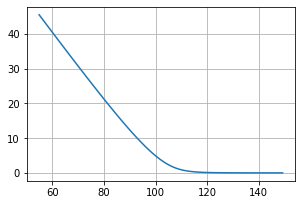

In [40]:
plt.plot(strike_array,opt_price)
plt.grid()

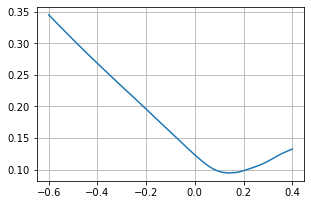

In [41]:
plt.plot(lm,iv)
plt.grid()

Question 4

Let's remind the initial parameters below  (related to the previous figures). We are going to produce similar graphs while varying one parameter (upward or downward) at each time.

In [42]:
# Baseline 

np.random.seed(0)

vov = 4
k_1 = 20
k_2 = 1.5
theta = 0.75
xi_0 = 0.025
rho_sx1, rho_sx2, rho_x1x2 = -0.8, -0.7, 0.7
T = 1

ST_base = two_factor_bergomi_mc(vov,k_1,k_2,theta,rho_sx1,rho_sx2,rho_x1x2,xi_0,n_steps,N_sims)

opt_price_base = np.average(np.maximum(ST_base - strike_array.reshape(-1,1),0),axis=1)
iv_base = vec_find_vol_rat(opt_price_base, S_0, strike_array, T, 0, 'c')

In [48]:
def plot_smile_comparison(
    vov=4,
    k_1=20,
    k_2=1.5,
    theta=0.75,
    xi_0=0.025,
    rho_sx1=-0.8,
    rho_sx2=-0.7,
    rho_x1x2=0.7,
    T=1,
    label="modified"
):
    np.random.seed(0)

    ST = two_factor_bergomi_mc(
        vov, k_1, k_2, theta,
        rho_sx1, rho_sx2, rho_x1x2,
        xi_0, n_steps, N_sims
    )

    opt_price = np.average(np.maximum(ST - strike_array.reshape(-1, 1), 0), axis=1)
    intrinsic = np.maximum(S_0 - strike_array, 0)
    opt_price = np.maximum(opt_price, intrinsic + 1e-10)
    iv = vec_find_vol_rat(opt_price, S_0, strike_array, T, 0, 'c')

    plt.figure()
    plt.plot(strike_array, opt_price_base, label="baseline")
    plt.plot(strike_array, opt_price, label=label)
    plt.legend()
    plt.grid()
    plt.title("Call price vs strike")

    plt.figure()
    plt.plot(lm, iv_base, label="baseline")
    plt.plot(lm, iv, label=label)
    plt.legend()
    plt.grid()
    plt.title("Implied volatility smile")

##### VOV - (4 to 1)

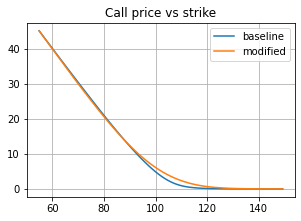

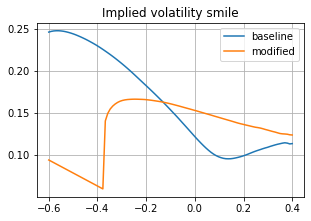

In [49]:
plot_smile_comparison(
    vov=1,
    k_1=20,
    k_2=1.5,
    theta=0.75,
    xi_0=0.025,
    rho_sx1=-0.8,
    rho_sx2=-0.7,
    rho_x1x2=0.7,
    T=1,
    label="modified"
)

##### VOV + (4 to 8)

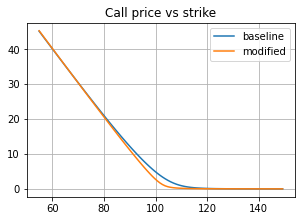

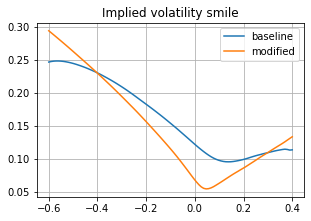

In [50]:
plot_smile_comparison(
    vov=8,
    k_1=20,
    k_2=1.5,
    theta=0.75,
    xi_0=0.025,
    rho_sx1=-0.8,
    rho_sx2=-0.7,
    rho_x1x2=0.7,
    T=1,
    label="modified"
)

k1 - (20 to 4)

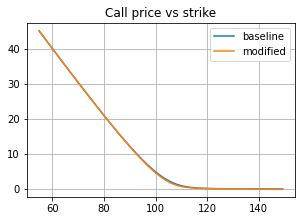

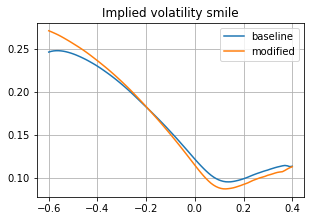

In [51]:
plot_smile_comparison(
    vov=4,
    k_1=4,
    k_2=1.5,
    theta=0.75,
    xi_0=0.025,
    rho_sx1=-0.8,
    rho_sx2=-0.7,
    rho_x1x2=0.7,
    T=1,
    label="modified"
)

k1 + (20 to 80)

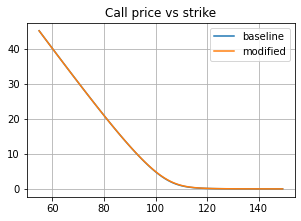

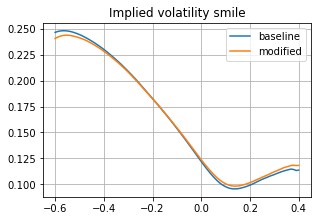

In [52]:
plot_smile_comparison(
    vov=4,
    k_1=80,
    k_2=1.5,
    theta=0.75,
    xi_0=0.025,
    rho_sx1=-0.8,
    rho_sx2=-0.7,
    rho_x1x2=0.7,
    T=1,
    label="modified"
)

k2 - (1.5 to 0.5)

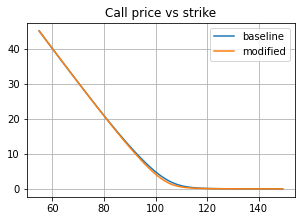

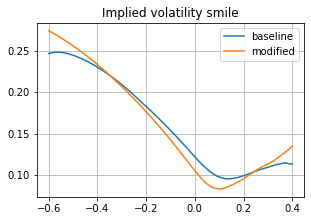

In [53]:
plot_smile_comparison(
    vov=4,
    k_1=20,
    k_2=0.5,
    theta=0.75,
    xi_0=0.025,
    rho_sx1=-0.8,
    rho_sx2=-0.7,
    rho_x1x2=0.7,
    T=1,
    label="modified"
)

k2 - (1.5 to 4.5)

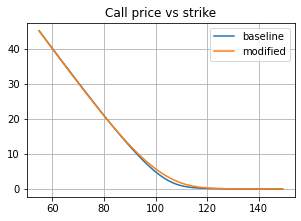

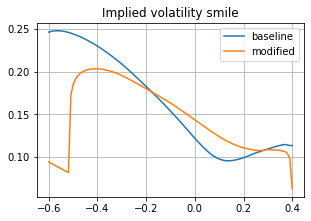

In [54]:
plot_smile_comparison(
    vov=4,
    k_1=20,
    k_2=4.5,
    theta=0.75,
    xi_0=0.025,
    rho_sx1=-0.8,
    rho_sx2=-0.7,
    rho_x1x2=0.7,
    T=1,
    label="modified"
)

theta - (0.75 to 0.25)

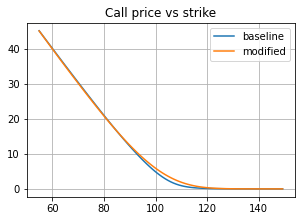

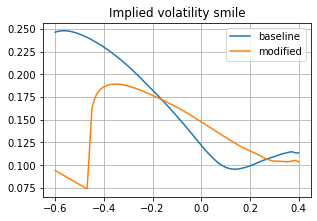

In [55]:
plot_smile_comparison(
    vov=4,
    k_1=20,
    k_2=1.5,
    theta=0.25,
    xi_0=0.025,
    rho_sx1=-0.8,
    rho_sx2=-0.7,
    rho_x1x2=0.7,
    T=1,
    label="modified"
)

theta + (0.25 to 0.95)

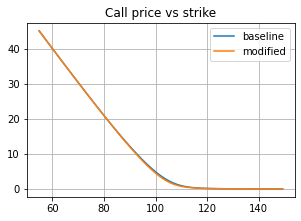

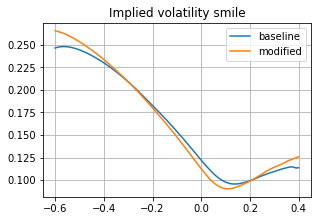

In [56]:
plot_smile_comparison(
    vov=4,
    k_1=20,
    k_2=1.5,
    theta=0.95,
    xi_0=0.025,
    rho_sx1=-0.8,
    rho_sx2=-0.7,
    rho_x1x2=0.7,
    T=1,
    label="modified"
)

rho_sx1 - (-0.8 to -1)

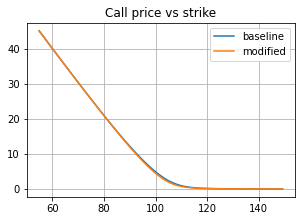

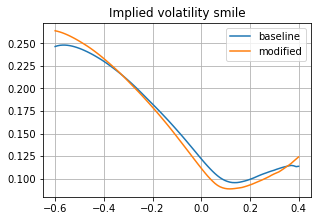

In [57]:
plot_smile_comparison(
    vov=4,
    k_1=20,
    k_2=1.5,
    theta=0.95,
    xi_0=0.025,
    rho_sx1=-1,
    rho_sx2=-0.7,
    rho_x1x2=0.7,
    T=1,
    label="modified"
)

rho_sx1 + (-0.8 to 0.5)

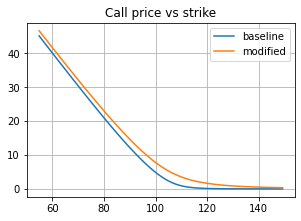

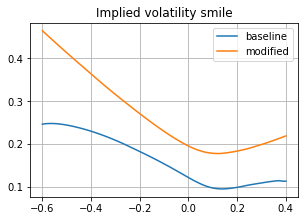

In [58]:
plot_smile_comparison(
    vov=4,
    k_1=20,
    k_2=1.5,
    theta=0.95,
    xi_0=0.025,
    rho_sx1=0.5,
    rho_sx2=-0.7,
    rho_x1x2=0.7,
    T=1,
    label="modified"
)

rho_sx2 - (-0.7 to -1)

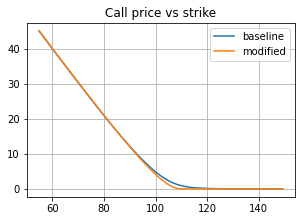

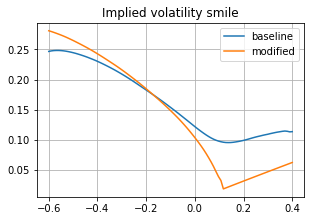

In [59]:
plot_smile_comparison(
    vov=4,
    k_1=20,
    k_2=1.5,
    theta=0.95,
    xi_0=0.025,
    rho_sx1=-0.8,
    rho_sx2=-1,
    rho_x1x2=0.7,
    T=1,
    label="modified"
)

rho_sx2 + (-0.7 to 0.5)

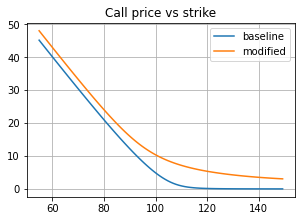

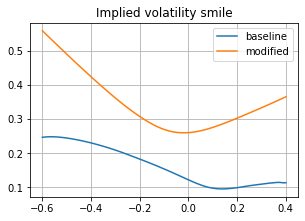

In [60]:
plot_smile_comparison(
    vov=4,
    k_1=20,
    k_2=1.5,
    theta=0.95,
    xi_0=0.025,
    rho_sx1=-0.8,
    rho_sx2=0.5,
    rho_x1x2=0.7,
    T=1,
    label="modified"
)

rho_x1_x2 - (0.7 to -0.5)

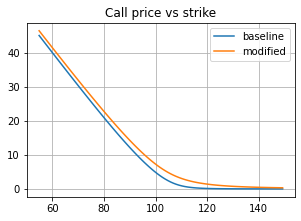

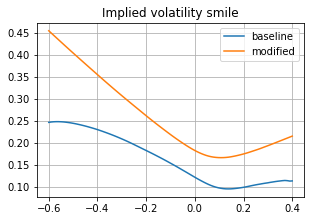

In [61]:
plot_smile_comparison(
    vov=4,
    k_1=20,
    k_2=1.5,
    theta=0.95,
    xi_0=0.025,
    rho_sx1=-0.8,
    rho_sx2=-0.7,
    rho_x1x2=-0.5,
    T=1,
    label="modified"
)

rho_x1_x2 + (0.7 to 0.9)

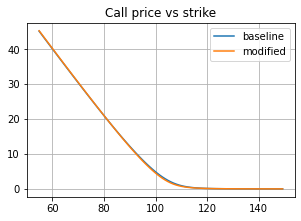

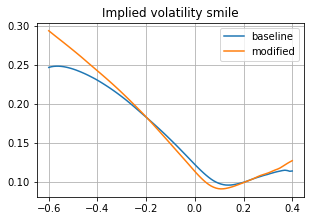

In [62]:
plot_smile_comparison(
    vov=4,
    k_1=20,
    k_2=1.5,
    theta=0.95,
    xi_0=0.025,
    rho_sx1=-0.8,
    rho_sx2=-0.7,
    rho_x1x2=0.9,
    T=1,
    label="modified"
)

T - (1 to 1/3)

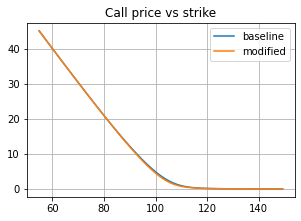

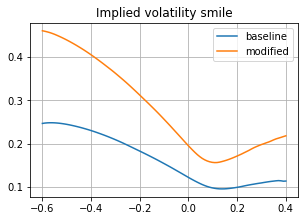

In [63]:
plot_smile_comparison(
    vov=4,
    k_1=20,
    k_2=1.5,
    theta=0.95,
    xi_0=0.025,
    rho_sx1=-0.8,
    rho_sx2=-0.7,
    rho_x1x2=0.7,
    T=1/3,
    label="modified"
)

T + (1 to 5)

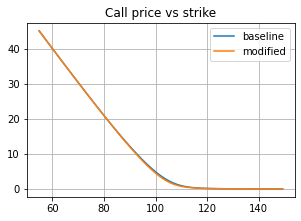

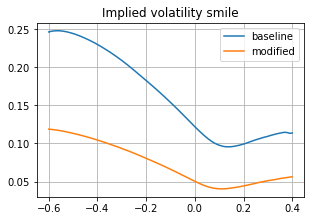

In [64]:
plot_smile_comparison(
    vov=4,
    k_1=20,
    k_2=1.5,
    theta=0.95,
    xi_0=0.025,
    rho_sx1=-0.8,
    rho_sx2=-0.7,
    rho_x1x2=0.7,
    T=5,
    label="modified"
)

We analyze the impact of the model parameters on the SPX implied volatility smile by varying one parameter at a time around a baseline configuration.

Vol-of-vol 

Increasing the vol-of-vol parameter significantly increases the curvature of the smile. The implied volatilities become higher in the wings, leading to a more pronounced smile. Conversely, lower values of vov produce flatter smiles. This confirms that vov mainly controls the overall level of volatility uncertainty and the strength of the smile.

Mean reversion parameters (k1, k2)

Increasing the mean reversion speeds reduces the variability of the volatility factors. As a result, the smile becomes flatter and implied volatilities decrease slightly. Lower values of k1 or k2 lead to more persistent volatility shocks and therefore more pronounced smiles.

Mixing parameter (theta)

The parameter theta controls the relative contribution of the two volatility factors. Changing theta modifies the shape of the smile in a more subtle way, mainly affecting the curvature and the balance between short-term and long-term effects. However, its impact is less significant than that of vov.

Correlation parameters (rho_sx1, rho_sx2)

The correlations between the spot and the volatility factors have a strong impact on the skew. More negative correlations lead to a steeper negative skew, meaning higher implied volatilities for low strikes. This is consistent with the leverage effect observed in equity markets.

Correlation between factors (rho_x1x2)

Changing the correlation between the two volatility factors affects the interaction between them and slightly modifies the curvature of the smile. However, its impact is more moderate compared to vov and spot-vol correlations.

Maturity (T)

As maturity increases, the smile tends to become smoother and less pronounced. Short-term smiles are more sensitive to volatility shocks, while long-term smiles are more stable due to averaging effects.

Question 5 

Fix $u>0$. By definition of the Bergomi model, the forward variance process
$$
\left(\xi_t^u\right)_{t\in[0,u]}
$$
is a martingale in $t$. In particular, for any $0\le t\le T\le u$,
$$
\mathbb{E}\left[\xi_u^u \mid \mathcal{F}_T\right]=\xi_T^u.
$$

Now, since
$$
\sigma_t^2=\xi_t^t,
$$
we obtain, by taking $t=u$,
$$
\xi_u^u=\sigma_u^2.
$$
Therefore,
$$
\xi_T^u=\mathbb{E}\left[\sigma_u^2\mid\mathcal{F}_T\right].
$$

Hence, for the VIX,
$$
\mathrm{VIX}_T^2=\frac{1}{\tau}\int_T^{T+\tau}\sigma_u^2\,du,
\qquad \text{with } \tau=\frac{30}{365},
$$
we get
$$
\mathbb{E}\left[\mathrm{VIX}_T^2\mid\mathcal{F}_T\right]
=
\frac{1}{\tau}\int_T^{T+\tau}\mathbb{E}\left[\sigma_u^2\mid\mathcal{F}_T\right]du
=
\frac{1}{\tau}\int_T^{T+\tau}\xi_T^u\,du.
$$
Since $\mathrm{VIX}_T^2$ is $\mathcal{F}_T$-measurable, this implies
$$
\mathrm{VIX}_T^2=\frac{1}{\tau}\int_T^{T+\tau}\xi_T^u\,du.
$$

In the two-factor Bergomi model, the forward variance is of the form
$$
\xi_T^u
=
\xi_0^u
\exp\left(
\omega X_T^u-\frac{\omega^2}{2}\chi(T,u)
\right),
$$
where
$$
X_T^u
=
\alpha\Bigl((1-\theta)e^{-k_1(u-T)}X_T^1+\theta e^{-k_2(u-T)}X_T^2\Bigr),
$$
and
$$
\alpha
=
\frac{1}{\sqrt{(1-\theta)^2+\theta^2+2\rho_{12}\theta(1-\theta)}}.
$$

Therefore,
$$
\mathrm{VIX}_T^2
=
\frac{1}{\tau}\int_T^{T+\tau}
\xi_0^u
\exp\left(
\omega\alpha\Bigl((1-\theta)e^{-k_1(u-T)}X_T^1+\theta e^{-k_2(u-T)}X_T^2\Bigr)
-\frac{\omega^2}{2}\chi(T,u)
\right)\,du.
$$

This shows that, in the two-factor Bergomi model, there exists a deterministic function $\psi$ such that
$$
\mathrm{VIX}_T=\psi(T,X_T^1,X_T^2),
$$
namely
$$
\psi(T,x_1,x_2)
=
\left[
\frac{1}{\tau}\int_T^{T+\tau}
\xi_0^u
\exp\left(
\omega\alpha\Bigl((1-\theta)e^{-k_1(u-T)}x_1+\theta e^{-k_2(u-T)}x_2\Bigr)
-\frac{\omega^2}{2}\chi(T,u)
\right)\,du
\right]^{1/2}.
$$

If the initial forward variance curve is constant, i.e.
$$
\xi_0^u\equiv \xi_0,
$$
then
$$
\psi(T,x_1,x_2)
=
\left[
\frac{\xi_0}{\tau}\int_T^{T+\tau}
\exp\left(
\omega\alpha\Bigl((1-\theta)e^{-k_1(u-T)}x_1+\theta e^{-k_2(u-T)}x_2\Bigr)
-\frac{\omega^2}{2}\chi(T,u)
\right)\,du
\right]^{1/2}.
$$

Question 6


Maturity T = 0.0833
  n_gh = 10   VIX future = 0.143929
  n_gh = 20   VIX future = 0.143929
  n_gh = 30   VIX future = 0.143929
  n_gh = 50   VIX future = 0.143929

Maturity T = 0.1667
  n_gh = 10   VIX future = 0.134728
  n_gh = 20   VIX future = 0.134728
  n_gh = 30   VIX future = 0.134728
  n_gh = 50   VIX future = 0.134728

Maturity T = 0.2500
  n_gh = 10   VIX future = 0.128115
  n_gh = 20   VIX future = 0.128115
  n_gh = 30   VIX future = 0.128115
  n_gh = 50   VIX future = 0.128115

Maturity T = 0.3333
  n_gh = 10   VIX future = 0.123214
  n_gh = 20   VIX future = 0.123214
  n_gh = 30   VIX future = 0.123214
  n_gh = 50   VIX future = 0.123214


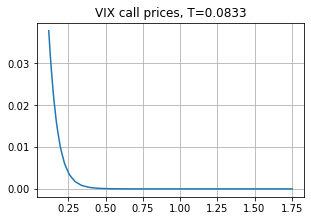

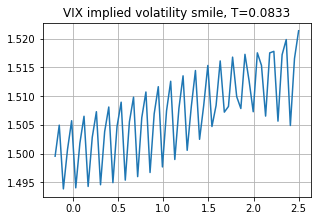

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.hermite import hermgauss
from math import sqrt, exp, log
from scipy.stats import norm
from scipy.optimize import brentq


#Preliminary functions

def covar(k1, k2, rho, t):
    return rho * (1.0 - np.exp(-(k1 + k2) * t)) / (k1 + k2)


def alpha_bergomi(theta, rho_x1x2):
    return 1.0 / np.sqrt((1 - theta)**2 + theta**2 + 2 * rho_x1x2 * theta * (1 - theta))


def chi_T_u(T, u, k1, k2, theta, rho_x1x2, alpha):
    """
    chi(T,u) = Var(X_T^u), where
    X_T^u = alpha * [ (1-theta)e^{-k1(u-T)} X_T^1 + theta e^{-k2(u-T)} X_T^2 ].
    """
    a1 = (1 - theta) * np.exp(-k1 * (u - T))
    a2 = theta * np.exp(-k2 * (u - T))

    var = (
        a1**2 * covar(k1, k1, 1.0, T)
        + a2**2 * covar(k2, k2, 1.0, T)
        + 2.0 * a1 * a2 * covar(k1, k2, rho_x1x2, T)
    )
    return alpha**2 * var


def x_T_u(T, u, x1, x2, k1, k2, theta, rho_x1x2):
    """
    X_T^u as a deterministic function of X_T^1 and X_T^2.
    """
    alpha = alpha_bergomi(theta, rho_x1x2)
    return alpha * (
        (1 - theta) * np.exp(-k1 * (u - T)) * x1
        + theta * np.exp(-k2 * (u - T)) * x2
    )


def psi_vix(
    T, x1, x2, tau,
    vov, k1, k2, theta, rho_x1x2,
    xi0_func,
    n_u=50
):
    """
    Computes VIX_T = psi(T, x1, x2)
    via
        VIX_T^2 = (1/tau) ∫_T^{T+tau} xi_T^u du
    with
        xi_T^u = xi0(u) * exp( vov * X_T^u - 0.5 * vov^2 * chi(T,u) )

    xi0_func must be a function u -> xi0(u).
    For a flat initial curve, use xi0_func = lambda u: xi0_const.
    """
    alpha = alpha_bergomi(theta, rho_x1x2)
    uu = np.linspace(T, T + tau, n_u)

    values = []
    for u in uu:
        xTu = alpha * (
            (1 - theta) * np.exp(-k1 * (u - T)) * x1
            + theta * np.exp(-k2 * (u - T)) * x2
        )
        chi = chi_T_u(T, u, k1, k2, theta, rho_x1x2, alpha)
        xi_T_u = xi0_func(u) * np.exp(vov * xTu - 0.5 * vov**2 * chi)
        values.append(xi_T_u)

    vix_sq = np.trapz(values, uu) / tau
    return np.sqrt(vix_sq)



# Gaussian law of (X_T^1, X_T^2)

def gaussian_law_XT(T, k1, k2, rho_x1x2):
    """
    Returns mean vector and covariance matrix of (X_T^1, X_T^2).
    Since X_0^1 = X_0^2 = 0, the mean is zero.
    """
    mean = np.array([0.0, 0.0])

    c11 = covar(k1, k1, 1.0, T)
    c22 = covar(k2, k2, 1.0, T)
    c12 = covar(k1, k2, rho_x1x2, T)

    cov = np.array([
        [c11, c12],
        [c12, c22]
    ])
    return mean, cov

# Gauss-Hermite quadrature for Gaussian expectations

def gh_expectation_2d(func, mean, cov, n_gh):
    """
    Approximates E[f(X)] where X ~ N(mean, cov) in dimension 2.

    If Z ~ N(0, I_2), we write X = mean + L Z, where cov = L L^T.
    Then use the Gauss-Hermite identity:
        E[g(Z1,Z2)] = (1/pi) sum_{i,j} w_i w_j g(sqrt(2)x_i, sqrt(2)x_j)
    where (x_i, w_i) are Hermite nodes and weights.
    """
    nodes, weights = hermgauss(n_gh)
    L = np.linalg.cholesky(cov)

    total = 0.0
    for i in range(n_gh):
        for j in range(n_gh):
            z = np.array([np.sqrt(2.0) * nodes[i], np.sqrt(2.0) * nodes[j]])
            x = mean + L @ z
            total += weights[i] * weights[j] * func(x[0], x[1])

    return total / np.pi

# VIX future and VIX calls

def vix_future_price(
    T, tau, n_gh,
    vov, k1, k2, theta, rho_x1x2,
    xi0_func,
    n_u=50
):
    mean, cov = gaussian_law_XT(T, k1, k2, rho_x1x2)

    def payoff(x1, x2):
        return psi_vix(
            T, x1, x2, tau,
            vov, k1, k2, theta, rho_x1x2,
            xi0_func, n_u=n_u
        )

    return gh_expectation_2d(payoff, mean, cov, n_gh)


def vix_call_price(
    K, T, tau, n_gh,
    vov, k1, k2, theta, rho_x1x2,
    xi0_func,
    n_u=50
):
    mean, cov = gaussian_law_XT(T, k1, k2, rho_x1x2)

    def payoff(x1, x2):
        vix = psi_vix(
            T, x1, x2, tau,
            vov, k1, k2, theta, rho_x1x2,
            xi0_func, n_u=n_u
        )
        return max(vix - K, 0.0)

    return gh_expectation_2d(payoff, mean, cov, n_gh)

def compute_vix_smile_for_maturity(
    T,
    tau,
    n_gh,
    lm_grid,
    vov, k1, k2, theta, rho_x1x2,
    xi0_func,
    n_u=50
):
    """
    For one maturity T:
      - compute the VIX future
      - define strikes K = F_vix * exp(log-moneyness)
      - compute VIX call prices
      - invert Black formula to get implied vols
    """
    F_vix = vix_future_price(
        T, tau, n_gh,
        vov, k1, k2, theta, rho_x1x2,
        xi0_func, n_u=n_u
    )

    strikes = F_vix * np.exp(lm_grid)

    call_prices = np.array([
        vix_call_price(
            K, T, tau, n_gh,
            vov, k1, k2, theta, rho_x1x2,
            xi0_func, n_u=n_u
        )
        for K in strikes
    ])

    iv = blackscholes_impv(strikes, T, F_vix, call_prices, r=0, q=0, callput='call')

    return F_vix, strikes, call_prices, iv

# Example

# Baseline parameters
vov = 4.0
k1 = 20.0
k2 = 1.5
theta = 0.75
rho_x1x2 = 0.7

# flat initial forward variance curve
xi0_const = 0.025
xi0_func = lambda u: xi0_const

tau = 30.0 / 365.0
lm_grid = np.linspace(-0.2, 2.5, 60)

maturity_list = [1/12, 2/12, 3/12, 4/12]

# Convergence test on the VIX future
for T in maturity_list:
    print(f"\nMaturity T = {T:.4f}")
    for n_gh in [10, 20, 30, 50]:
        F_vix = vix_future_price(
            T, tau, n_gh,
            vov, k1, k2, theta, rho_x1x2,
            xi0_func, n_u=50
        )
        print(f"  n_gh = {n_gh:2d}   VIX future = {F_vix:.6f}")

# Example: plot the VIX smile for T = 1/12 with 50 GH points
T_plot = 1/12
F_vix, strikes, call_prices, iv = compute_vix_smile_for_maturity(
    T_plot, tau, 50, lm_grid,
    vov, k1, k2, theta, rho_x1x2,
    xi0_func, n_u=50
)

plt.figure()
plt.plot(strikes, call_prices)
plt.grid()
plt.title(f"VIX call prices, T={T_plot:.4f}")

plt.figure()
plt.plot(lm_grid, iv)
plt.grid()
plt.title(f"VIX implied volatility smile, T={T_plot:.4f}")
plt.show()

The Gauss-Hermite quadrature converges very rapidly. Even with 10 points, the VIX future price is already stable, and increasing the number of quadrature points does not significantly change the result.

The VIX call prices decrease rapidly with the strike and become negligible for large log-moneyness values, as expected.
The implied volatility curve is irregular due to numerical instability in the Black inversion when option prices are very small.
Consequently, the smile is only reliable close to the at-the-money region

Question 7

Impact of vol-of-vol on the VIX future:

vov = 1.0
  T = 0.0833, VIX future = 0.157186
  T = 0.1667, VIX future = 0.156537
  T = 0.2500, VIX future = 0.156044
  T = 0.3333, VIX future = 0.155663

vov = 4.0
  T = 0.0833, VIX future = 0.143929
  T = 0.1667, VIX future = 0.134728
  T = 0.2500, VIX future = 0.128115
  T = 0.3333, VIX future = 0.123214

vov = 8.0
  T = 0.0833, VIX future = 0.108744
  T = 0.1667, VIX future = 0.083646
  T = 0.2500, VIX future = 0.068506
  T = 0.3333, VIX future = 0.058695


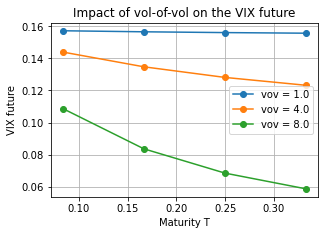

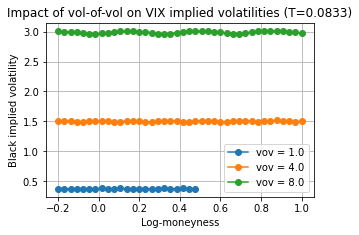

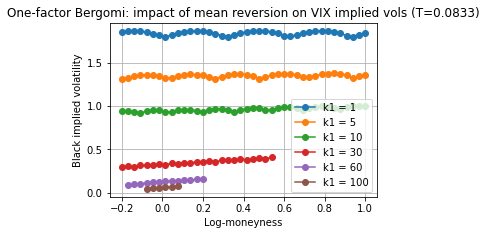

In [66]:
tau = 30.0 / 365.0
lm_grid = np.linspace(-0.2, 1.0, 40)   
n_gh = 30                               
n_u = 50

# Baseline parameters
vov_base = 4.0
k1_base = 20.0
k2_base = 1.5
theta_base = 0.75
rho_x1x2_base = 0.7

maturity_list = [1/12, 2/12, 3/12, 4/12]



# Impact of vol-of-vol on the VIX future


vov_list = [1.0, 4.0, 8.0]

plt.figure()

for vov in vov_list:
    vix_futures = []

    for T in maturity_list:
        F_vix = vix_future_price(
            T, tau, n_gh,
            vov, k1_base, k2_base, theta_base, rho_x1x2_base,
            xi0_func, n_u=n_u
        )
        vix_futures.append(F_vix)

    plt.plot(maturity_list, vix_futures, marker='o', label=f"vov = {vov}")

plt.grid()
plt.legend()
plt.title("Impact of vol-of-vol on the VIX future")
plt.xlabel("Maturity T")
plt.ylabel("VIX future")



# Impact of vol-of-vol on the VIX smile


T_plot = 1/12  

plt.figure()

for vov in vov_list:
    F_vix, strikes, call_prices, iv = compute_vix_smile_for_maturity(
        T_plot, tau, n_gh, lm_grid,
        vov, k1_base, k2_base, theta_base, rho_x1x2_base,
        xi0_func, n_u=n_u
    )

    mask = np.isfinite(iv) & (call_prices > 1e-8)
    plt.plot(lm_grid[mask], iv[mask], marker='o', label=f"vov = {vov}")

plt.grid()
plt.legend()
plt.title(f"Impact of vol-of-vol on VIX implied volatilities (T={T_plot:.4f})")
plt.xlabel("Log-moneyness")
plt.ylabel("Black implied volatility")



# One-factor Bergomi: theta = 0
# Impact of mean reversion k1 on VIX implied volatilities


theta_one_factor = 0.0
k1_list = [1, 5, 10, 30, 60, 100]

plt.figure()

for k1 in k1_list:
    F_vix, strikes, call_prices, iv = compute_vix_smile_for_maturity(
        T_plot, tau, n_gh, lm_grid,
        vov_base, k1, k2_base, theta_one_factor, rho_x1x2_base,
        xi0_func, n_u=n_u
    )

    mask = np.isfinite(iv) & (call_prices > 1e-8)
    plt.plot(lm_grid[mask], iv[mask], marker='o', label=f"k1 = {k1}")

plt.grid()
plt.legend()
plt.title(f"One-factor Bergomi: impact of mean reversion on VIX implied vols (T={T_plot:.4f})")
plt.xlabel("Log-moneyness")
plt.ylabel("Black implied volatility")



# numerical values of the VIX future


print("Impact of vol-of-vol on the VIX future:")
for vov in vov_list:
    print(f"\nvov = {vov}")
    for T in maturity_list:
        F_vix = vix_future_price(
            T, tau, n_gh,
            vov, k1_base, k2_base, theta_base, rho_x1x2_base,
            xi0_func, n_u=n_u
        )
        print(f"  T = {T:.4f}, VIX future = {F_vix:.6f}")


plt.show()

The numerical results show that increasing the vol-of-vol parameter decreases the VIX future price in this specification of the Bergomi model. This is due to the fact that the VIX is the square root of an average future variance, and the square-root function is concave. As the dispersion of future variance increases, this concavity effect lowers the expectation of the VIX itself.

By contrast, increasing vol-of-vol clearly increases VIX implied volatilities. Indeed, a larger vol-of-vol makes the distribution of the VIX more dispersed, which raises VIX option prices and therefore implied volatilities.

In the one-factor Bergomi model with theta = 0, increasing the mean reversion parameter (k1) lowers VIX implied volatilities. When mean reversion is faster, volatility shocks decay more quickly and have a smaller impact on the average forward variance over the next 30 days. As a result, the distribution of the VIX becomes less spread out and VIX options become cheaper.